# Effects in oxygen electrocatalysis

The goal of ORR catalyst design is simple: find a material that binds OH exactly 0.1 eV weaker than pure Pt(111). To achieve this we need to understand which physical handles are available to tune the OH adsorption energy without resorting to trial-and-error.

This notebook systematically explores the electronic effect (d-band center position controls bond strength), the facet effect (surface orientation determines the coordination number of the binding site), the strain effect (stretching or compressing the lattice shifts the d-band width and center), the curvature effect (bending a 2D catalyst sheet changes the bonding geometry at the active site), the ligand effect (subsurface atoms modify the electron density seen by the surface metal through-bond), and the coordination effect (a fifth axial ligand in a molecular catalyst like FePc alters the electron density at the sixth binding site).

The UMA calculator is used for the metal surface effects. For the curvature effect on NiN₄-doped graphene nanoribbons, GFN1-xTB is used because UMA was not trained on M-N-C materials. A shared relax() function handles all geometry optimizations, using atom tags to selectively freeze substrate atoms (tag 42) and identify adsorbate atoms for reference slab energy extraction (tag 53).

https://www.youtube.com/watch?v=samwNUSNv5g

In [1]:
%%capture
!pip install fairchem-core ase

The UMA model is distributed under the FAIR Chemistry License by Meta, available at https://huggingface.co/facebook/UMA/blob/main/LICENSE. By running this notebook you agree to its terms. To use the model in your own environment, go to Hugging Face (huggingface.co), create an account, generate an access token under Settings > Access Tokens, and download the model via the fairchem API. Since tokens are personal and should not be shared, in this notebook we provide the model file via a direct Google Drive link instead.

In [2]:
!gdown 1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX -O uma-s-1p1.pt

Downloading...
From (original): https://drive.google.com/uc?id=1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX
From (redirected): https://drive.google.com/uc?id=1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX&confirm=t&uuid=7bf45195-9468-44fc-8614-f949f40f0197
To: /content/uma-s-1p1.pt
100% 1.17G/1.17G [00:16<00:00, 70.8MB/s]


In [3]:
from ase import Atom, Atoms
from ase.build import fcc111, fcc110, fcc100, fcc211, add_adsorbate, graphene_nanoribbon
from ase.constraints import FixAtoms
from ase.data import atomic_numbers, reference_states
from ase.data.pubchem import pubchem_atoms_search
from ase.neighborlist import NeighborList
from ase.optimize import FIRE
from ase.visualize import view

from fairchem.core import FAIRChemCalculator
from fairchem.core.units.mlip_unit import MLIPPredictUnit
from scipy.stats import linregress

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

We load the UMA machine learning potential and define two helper functions. The `relax` function handles geometry optimization and optionally strips the adsorbate to compute the clean slab energy from the same structure, saving us from building separate models. The `model_strain` function builds a Pt(111) slab with OH adsorbed and assigns atom tags to control which atoms are fixed during relaxation.

In [4]:
model_path = '/content/uma-s-1p1.pt'
predictor = MLIPPredictUnit(model_path, device='cpu')
calc = FAIRChemCalculator(predictor, task_name='oc20')

**Helper Functions for Adsorption and Constraints**
To streamline our workflow, we define some clever functions here. We will assign the tag "42" to constrain specific atoms during relaxation. We also assign the tag "53" to O and H atoms; this allows us to easily strip away the O adsorbate to calculate the energy of the bare slab, saving us from building two entirely separate models. We also set our standard parameters so our plotted figures look nice.

In [5]:
def relax(atoms, file_name, remove_OH=False, fmax=0.1, steps=25):
  atoms.set_constraint(FixAtoms(indices=[atom.index for atom in atoms if atom.tag == 42]))

  if remove_OH:
    atoms = atoms[[atom.index for atom in atoms if atom.tag != 53]]

  atoms.calc = calc

  opt = FIRE(atoms, trajectory=f'{file_name}.traj', logfile=f'{file_name}.log')
  opt.run(fmax=fmax, steps=steps)

  return atoms, atoms.get_potential_energy()


def model_strain(metal='Pt', Nx=3, Ny=3, Nz=5, scale=1.0):
  ref_state = reference_states[atomic_numbers[metal]]

  if not (ref_state and 'a' in ref_state):
    raise ValueError(f'Lattice constant not found for element: {metal}')

  lattice = ref_state['a'] * scale

  atoms = fcc111(metal, size=(Nx, Ny, Nz), a=lattice, vacuum=10.0)
  atoms.translate([0, 0, -4])

  target_index = Nx * Ny * (Nz - 1)

  adsorbate = Atoms('OH', positions=[
    (0, 0, 0),
    (0.7, 0, 0.7)
  ])

  add_adsorbate(atoms, adsorbate, 1.8, atoms[target_index].position[:2])

  for atom in atoms:
    if atom.index < target_index:
      atom.tag = 42
    elif atom.index >= len(atoms) - 2:
      atom.tag = 53
    else:
      atom.tag = 0

  return atoms

### Set parameters for figures

In [6]:
l = 8.25 / 2.54

plt.rc('figure', figsize=(l, l))
plt.rc('figure', dpi=100)
plt.rc('lines', linewidth=4)
plt.rc('font', size=10)
plt.rc('font', family='sans-serif')
plt.rc('axes', titlesize=10)
plt.rc('axes', labelsize=9)
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)
plt.rc('legend', fontsize=8)
plt.rc('figure', titlesize=10)
colors = ['#1965B0', '#7BAFDE', '#90C987', '#F1932D', '#DC050C']

## Electronic effect

The electronic effect in electrocatalysis refers to how the electronic structure of a catalyst influences its ability to bind with molecules on its surface. This effect is crucial because the strength of this binding can significantly impact reaction rates.

One way to understand the electronic effect is through d-band theory. In transition metals, electrons in the d-band play a major role in bonding with molecules like OH. The theory suggests that the closer the d-band is to the Fermi level (the surface’s main energy level), the stronger the bond with OH. When the d-band is close, more d-electrons are available to interact with the molecule, creating a tighter bond.

Adjusting the d-band, by changing the metal's composition or structure, helps control binding strength, making the electronic effect a powerful tool for designing better catalysts.

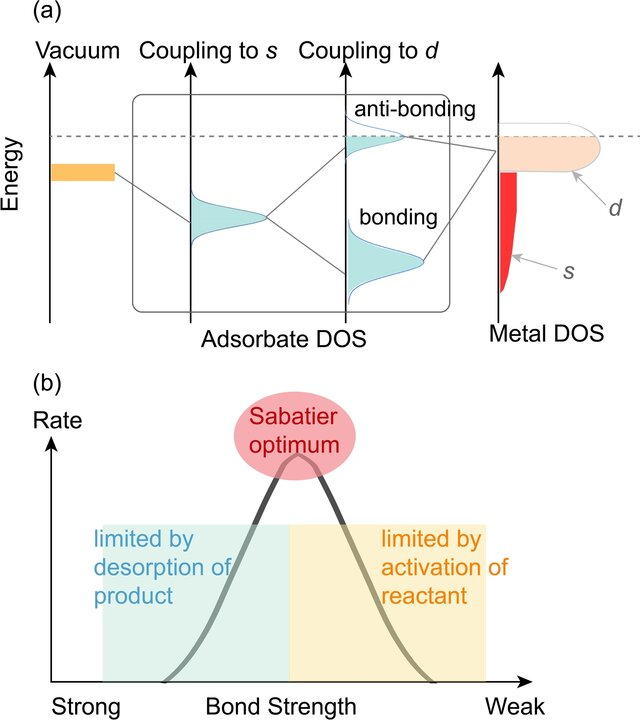

References:

https://www.nature.com/articles/srep35916

https://link.springer.com/article/10.1007/s11244-012-9794-2

The electronic effect describes how the d-band center of a transition metal controls its binding strength to reaction intermediates. According to d-band theory, metals with a d-band center closer to the Fermi level bind OH more strongly. We calculate OH adsorption energies on Pt, Ag, Pd, and Ir and plot them against literature d-band center values to confirm this correlation.

In [7]:
%%time
Nx, Ny, Nz = 2, 2, 3
rows = []

for metal in ['Pt', 'Ag', 'Pd', 'Ir']:
  name = f'dband_{metal}'

  atoms = model_strain(metal=metal, Nx=Nx, Ny=Ny, Nz=Nz, scale=1.0)
  atoms, energy_with_OH = relax(atoms, f'{name}-OH', remove_OH=False)
  atoms, energy_without_OH = relax(atoms, f'{name}', remove_OH=True)

  rows.append({
    'metal': metal,
    'relative_energy': energy_with_OH - energy_without_OH
  })

df_dband = pd.DataFrame(rows)

##-Literature d-band centers, Hammer-Norskov
dband_centers = {
  'Pt': -2.25,
  'Pd': -1.83,
  'Ir': -2.11,
  'Ag': -4.30
}

df_dband['dbandcenter'] = df_dband['metal'].map(dband_centers)
df_dband

CPU times: user 3min 13s, sys: 208 ms, total: 3min 13s
Wall time: 48.5 s


,metal,relative_energy,dbandcenter
0,Pt,-9.662675,-2.25
1,Ag,-9.357820,-4.30
2,Pd,-9.674468,-1.83
3,Ir,-9.980994,-2.11


In [8]:
df_dband

,metal,relative_energy,dbandcenter
0,Pt,-9.662675,-2.25
1,Ag,-9.357820,-4.30
2,Pd,-9.674468,-1.83
3,Ir,-9.980994,-2.11


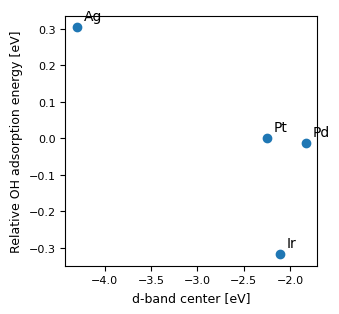

In [9]:
reference_energy = df_dband.loc[df_dband['metal'] == 'Pt', 'relative_energy'].values[0]
df_dband['relative_energy_difference'] = df_dband['relative_energy'] - reference_energy

plt.figure()
plt.plot(df_dband['dbandcenter'], df_dband['relative_energy_difference'], marker='o', linestyle='')

for _, row in df_dband.iterrows():
  plt.annotate(
    row['metal'],
    (row['dbandcenter'], row['relative_energy_difference']),
    textcoords='offset points',
    xytext=(5, 5)
  )

plt.xlabel('d-band center [eV]')
plt.ylabel('Relative OH adsorption energy [eV]')
plt.show()

!mkdir -p dband_effect && mv dband*.traj dband*.log dband_effect/

## Facet effect

The facet effect refers to how different surfaces, or "facets," of a single crystal catalyst can influence the strength of OH bonding. In crystal structures, each facet (or surface type) has a unique arrangement of atoms, which affects how molecules like OH bind to it. For example, in a cubic crystal, the (111) facet has a dense, flat arrangement of atoms, while the (211) facet has more exposed atoms at edges.

When catalysts are engineered with specific facets or a higher proportion of edges (such as by creating more stepped surfaces), they can adjust the binding strength of OH. By carefully selecting and controlling these facets, scientists can design catalysts that optimize OH bonding strength for faster reactions.

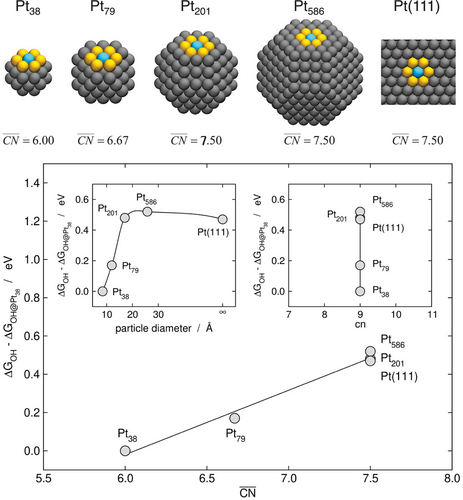

References:

https://www.nature.com/articles/nchem.2226#MOESM347

https://onlinelibrary.wiley.com/doi/10.1002/advs.202207644

The facet effect describes how different surface orientations of the same metal expose atoms with different coordination numbers, which in turn affects OH binding strength. We compute OH adsorption energies on four Pt facets and plot them against the coordination number of the adsorption site. Note that this calculation takes at least 40 minutes to run.

In [10]:
def create_fcc_model(metal='Pt', facet='111', Nx=3, Ny=3, Nz=4, ad=0):
  ref_state = reference_states[atomic_numbers[metal]]

  if not (ref_state and 'a' in ref_state):
    raise ValueError(f'Lattice constant not found for element: {metal}')

  d = ref_state['a'] / np.sqrt(2)

  if facet == '111':
    atoms = fcc111(metal, size=(Nx, Ny, Nz), vacuum=10.0)
  elif facet == '110':
    atoms = fcc110(metal, size=(Nx, Ny, Nz), vacuum=10.0)
  elif facet == '100':
    atoms = fcc100(metal, size=(Nx, Ny, Nz), vacuum=10.0)
  elif facet == '211':
    atoms = fcc211(metal, size=(Nx, Ny, Nz), vacuum=10.0)
  else:
    raise ValueError(f'Unsupported facet: {facet}')

  atoms.translate([0, 0, -4])
  atoms.pbc = [True, True, True]

  outermost_atom = max(atoms, key=lambda atom: atom.position[2])

  if ad == 1:
    adsorbate = Atoms('Pt', positions=[(0, 0, 0)])
    add_adsorbate(atoms, adsorbate, d, outermost_atom.position[:2])
  elif ad == 2:
    adsorbate = Atoms('Pt2', positions=[
      (0, 0, 0),
      (-d, 0, 0)
    ])
    add_adsorbate(atoms, adsorbate, d, outermost_atom.position[:2])
  elif ad == 3:
    adsorbate = Atoms('Pt3', positions=[
      (0, 0, 0),
      (-d, 0, 0),
      (0, d, 0)
    ])
    add_adsorbate(atoms, adsorbate, d, outermost_atom.position[:2])
  elif ad == 4:
    adsorbate = Atoms('Pt4', positions=[
      (0, 0, 0),
      (-d, 0, 0),
      (0, d, 0),
      (-d, d, 0)
    ])
    add_adsorbate(atoms, adsorbate, d, outermost_atom.position[:2])
  elif ad != 0:
    raise ValueError(f'Unsupported value for ad: {ad}')

  height = 1.8

  if ad > 0:
    height = 1.8 + d

  adsorbate = Atoms('OH', positions=[
    (0, 0, 0),
    (0.7, 0, 0.7)
  ])

  add_adsorbate(atoms, adsorbate, height, outermost_atom.position[:2])

  atoms = atoms[[atom.index for atom in sorted(atoms, key=lambda atom: atom.position[2])]]

  target_index = Nx * Ny * (Nz - 1)

  for atom in atoms:
    if atom.index < target_index:
      atom.tag = 42
    elif atom.index >= len(atoms) - 2:
      atom.tag = 53
    else:
      atom.tag = 0

  return atoms


def get_cn(atoms, cutoff=3.0):
  oxygen_index = next(i for i, atom in enumerate(atoms) if atom.symbol == 'O')

  cutoffs = [cutoff] * len(atoms)
  nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
  nl.update(atoms)

  indices, offsets = nl.get_neighbors(oxygen_index)

  nearest_atom_index = None
  min_distance = float('inf')

  for i, offset in zip(indices, offsets):
    if atoms[i].symbol != 'H':
      distance = np.linalg.norm(
        atoms[oxygen_index].position - (atoms[i].position + np.dot(offset, atoms.cell))
      )

      if distance < min_distance:
        nearest_atom_index = i
        min_distance = distance

  return get_scaled_cn(atoms, nearest_atom_index, cutoff)


def get_scaled_cn(atoms, target_index, cutoff=3.0):
  cutoffs = [cutoff] * len(atoms)
  nl = NeighborList(cutoffs, self_interaction=False, bothways=True)
  nl.update(atoms)

  target_symbol = atoms[target_index].symbol
  indices, offsets = nl.get_neighbors(target_index)
  same_type_neighbors = []

  for i, offset in zip(indices, offsets):
    distance = np.linalg.norm(
      atoms[target_index].position - (atoms[i].position + np.dot(offset, atoms.cell))
    )

    if atoms[i].symbol == target_symbol and distance <= cutoff:
      same_type_neighbors.append(i)

  cn_sum = 0

  for neighbor_index in same_type_neighbors:
    neighbor_indices, neighbor_offsets = nl.get_neighbors(neighbor_index)
    cn_count = 0

    for i, offset in zip(neighbor_indices, neighbor_offsets):
      distance = np.linalg.norm(
        atoms[neighbor_index].position - (atoms[i].position + np.dot(offset, atoms.cell))
      )

      if atoms[i].symbol == target_symbol and distance <= cutoff:
        cn_count += 1

    cn_sum += cn_count

  return cn_sum / 12

In [11]:
%%time
metal = 'Pt'
Nx, Ny, Nz = 3, 4, 3
rows = []

for facet in ['111', '110', '100', '211']:
  name = f'cn_{metal}_{facet}'
  print(f'Running {name}...', flush=True)

  atoms = create_fcc_model(metal=metal, facet=facet, Nx=Nx, Ny=Ny, Nz=Nz, ad=0)
  atoms, energy_with_OH = relax(atoms, f'{name}-OH', remove_OH=False)

  cn = get_cn(atoms)

  atoms, energy_without_OH = relax(atoms, f'{name}', remove_OH=True)

  rows.append({
    'metal': metal,
    'facet': facet,
    'cn': cn,
    'relative_energy': energy_with_OH - energy_without_OH
  })

df_cn = pd.DataFrame(rows)
df_cn

Running cn_Pt_111...
Running cn_Pt_110...
Running cn_Pt_100...
Running cn_Pt_211...
CPU times: user 6min 14s, sys: 485 ms, total: 6min 15s
Wall time: 1min 33s


,metal,facet,cn,relative_energy
0,Pt,111,7.500000,-9.643194
1,Pt,110,5.083333,-10.285706
2,Pt,100,6.666667,-9.853616
3,Pt,211,5.500000,-10.007321


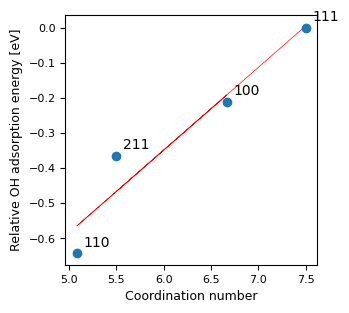

In [12]:
reference_energy = df_cn.loc[df_cn['facet'] == '111', 'relative_energy'].values[0]
df_cn['relative_energy_difference'] = df_cn['relative_energy'] - reference_energy

slope, intercept, _, _, _ = linregress(df_cn['cn'], df_cn['relative_energy_difference'])

plt.figure()
plt.plot(df_cn['cn'], slope * df_cn['cn'] + intercept, linestyle='-', color='r', linewidth=0.5)
plt.plot(df_cn['cn'], df_cn['relative_energy_difference'], marker='o', linestyle='')

for _, row in df_cn.iterrows():
  plt.annotate(
    row['facet'],
    (row['cn'], row['relative_energy_difference']),
    textcoords='offset points',
    xytext=(5, 5)
  )

plt.xlabel('Coordination number')
plt.ylabel('Relative OH adsorption energy [eV]')
plt.show()

!mkdir -p cn_effect && mv cn_*.traj cn_*.log cn_effect/

## Strain effect

The strain effect in catalysis is a way to adjust how strongly molecules like OH bind to a catalyst by slightly stretching or compressing the surface. When a catalyst’s surface is strained, the distance between atoms changes, which alters the electronic structure of the material. This change in structure can make it easier or harder for OH molecules to bind to the surface.

For example, if the surface is stretched (tensile strain), atoms move slightly farther apart, often weakening the bond with OH. Conversely, if the surface is compressed (compressive strain), atoms are closer together, which can strengthen the binding. By tuning the strain, scientists can find an optimal binding strength that enhances catalytic activity.

This approach allows for fine control over bonding without changing the material itself, making the strain effect a useful tool in catalyst design.

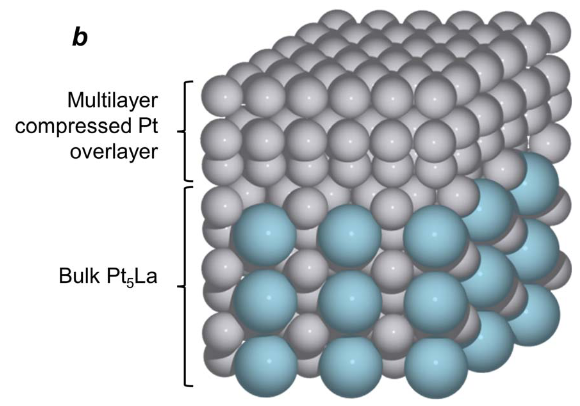

References:

https://pubs.rsc.org/en/content/articlelanding/2012/ee/c2ee03590a
https://www.science.org/doi/10.1126/science.aad8892

The strain effect describes how stretching or compressing a catalyst surface shifts its electronic structure and changes OH binding strength. We systematically vary the Pt(111) lattice parameter from -2% to +1% and track the resulting change in adsorption energy, showing that tensile strain strengthens binding while compressive strain weakens it.

In [13]:
%%time
metal = 'Pt'
Nx, Ny, Nz = 3, 3, 3
rows = []

for scale in [0.98, 0.99, 0.995, 1.0, 1.005, 1.01]:
  name = f'strain_{scale}_{metal}'
  print(f'Running {name}...', flush=True)

  atoms = model_strain(metal=metal, Nx=Nx, Ny=Ny, Nz=Nz, scale=scale)
  atoms, energy_with_OH = relax(atoms, f'{name}-OH', remove_OH=False)
  atoms, energy_without_OH = relax(atoms, f'{name}', remove_OH=True)

  rows.append({
    'metal': metal,
    'scale': scale,
    'relative_energy': energy_with_OH - energy_without_OH
  })

df_strain = pd.DataFrame(rows)
df_strain

Running strain_0.98_Pt...
Running strain_0.99_Pt...
Running strain_0.995_Pt...
Running strain_1.0_Pt...
Running strain_1.005_Pt...
Running strain_1.01_Pt...
CPU times: user 7min 52s, sys: 459 ms, total: 7min 52s
Wall time: 1min 58s


,metal,scale,relative_energy
0,Pt,0.980,-9.615609
1,Pt,0.990,-9.622078
2,Pt,0.995,-9.615310
3,Pt,1.000,-9.664653
4,Pt,1.005,-9.686043
5,Pt,1.010,-9.706744


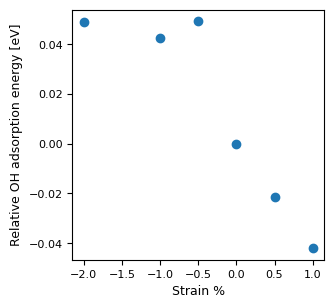

In [14]:
reference_energy = df_strain.loc[df_strain['scale'] == 1.0, 'relative_energy'].values[0]
df_strain['relative_energy_difference'] = df_strain['relative_energy'] - reference_energy
df_strain['scale_percent'] = (df_strain['scale'] - 1) * 100

plt.figure()
plt.plot(df_strain['scale_percent'], df_strain['relative_energy_difference'], marker='o', linestyle='')
plt.xlabel('Strain %')
plt.ylabel('Relative OH adsorption energy [eV]')
plt.show()

!mkdir -p strain_effect && mv strain_*.traj strain_*.log strain_effect/

## Curvature effect

The surface curvature effect refers to how the curvature of a catalyst's surface influences its electronic properties and, consequently, its catalytic performance. In materials like Metal–Nitrogen–Carbon (M–N–C) catalysts, introducing curvature can modify the electronic structure of active sites, affecting the adsorption energies of reaction intermediates. This adjustment can enhance catalytic activities for reactions such as the oxygen reduction and evolution reactions (ORR/OER). By tailoring the surface curvature, it's possible to optimize the binding strength of intermediates, potentially overcoming limitations imposed by scaling relations and improving overall catalytic efficiency.

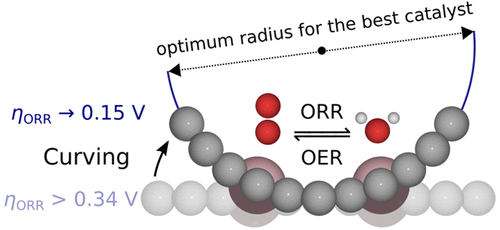

References:

https://pubs.rsc.org/en/content/articlelanding/2024/cy/d4cy00036f

https://pubs.acs.org/doi/full/10.1021/acsenergylett.3c00068

https://www.sciencedirect.com/science/article/pii/S1385894723055729

The curvature effect describes how bending a catalyst surface, such as an M-N-C sheet, modifies the bonding geometry at the active site and shifts the OH adsorption energy. We use sine and cosine functions to bend a graphene nanoribbon containing a Ni-N4 center at different radii of curvature and plot the adsorption energy against the inverse squared radius. Because UMA was not trained on M-N-C materials, we switch to GFN1-xTB for this section.

In [15]:
def add_OH_group(atoms, metal_index):
  ##-Get metal atom position
  x, y, z = atoms[metal_index].position

  ##-Add OH group
  atoms += Atoms('OH', positions=[
    (x, y + 1.8, z),
    (x, y + 2.7, z + 0.7)
  ])

  ##-Tag atoms
  for atom in atoms:
    if atom.index >= len(atoms) - 2:
      atom.tag = 53
    elif atom.symbol in ['N', atoms[metal_index].symbol]:
      atom.tag = 0
    else:
      atom.tag = 42


def create_base(metal='Co', curve=True):
  ##-Create nanoribbon
  atoms = graphene_nanoribbon(3.5, 2, saturated='True', type='armchair')

  ##-Substitute atoms with nitrogen
  for i in (10, 13, 18, 21):
    atoms[i].symbol = 'N'

  ##-Calculate metal position
  metal_pos = (atoms[11].position + atoms[12].position) / 2

  ##-Delete original atoms
  del atoms[[11, 12]]

  ##-Add metal atom
  atoms.append(Atom(metal, position=metal_pos))

  metal_index = 34
  x_center = atoms[metal_index].position[0]

  ##-Center all atoms along x-axis
  for atom in atoms:
    atom.position[0] -= x_center

  if curve:
    ##-Center atoms if curved
    atoms.center()
  else:
    ##-Center with vacuum for non-curved
    atoms.center(vacuum=8, axis=(0, 1))
    add_OH_group(atoms, metal_index)

  ##-Set periodic boundary conditions
  atoms.pbc = [True, True, True]

  return atoms


def create_curvature(atoms, r):
  for atom in atoms:
    ##-Calculate curvature angle
    theta = atom.position[0] / r

    ##-Curve positions
    atom.position[0] = r * np.sin(theta)
    atom.position[1] = -r * np.cos(theta)

  ##-Center with vacuum
  atoms.center(vacuum=8, axis=(0, 1))

  metal_index = 34
  add_OH_group(atoms, metal_index)

  return atoms

In [16]:
%%time
metal = 'Ni'

rows = []
for radius in [1000, 16, 8, 6, 4]:
  atoms = create_curvature(create_base(metal), radius)
  name = f'curvature_{radius}_{metal}N4'

  atoms, energy_with_OH = relax(atoms, f'{name}-OH', remove_OH=False)
  atoms, energy_without_OH = relax(atoms, f'{name}', remove_OH=True)

  rows.append({
    'metal': metal,
    'radius': radius,
    'relative_energy': energy_with_OH - energy_without_OH
  })

  del atoms

df_curvature = pd.DataFrame(rows)
df_curvature

CPU times: user 8min 29s, sys: 688 ms, total: 8min 30s
Wall time: 2min 7s


,metal,radius,relative_energy
0,Ni,1000,-8.826893
1,Ni,16,-8.795180
2,Ni,8,-8.745287
3,Ni,6,-8.692862
4,Ni,4,-8.521628


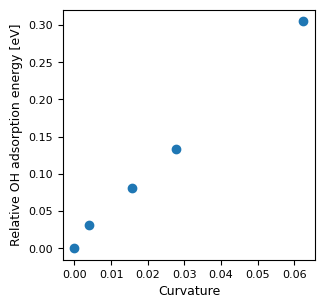

In [17]:
plt.figure()

##-Set reference energy at radius = 1000
reference_energy = df_curvature.loc[df_curvature['radius'] == 1000, 'relative_energy'].values[0]

##-Calculate relative energy and curvature
df_curvature['relative_energy_difference'] = df_curvature['relative_energy'] - reference_energy
df_curvature['curvature'] = 1 / df_curvature['radius']**2

##-Plot
plt.plot(df_curvature['curvature'], df_curvature['relative_energy_difference'], marker='o', linestyle='')
plt.xlabel('Curvature')
plt.ylabel('Relative OH adsorption energy [eV]')
plt.show()

In [18]:
!mkdir curvature_effect
!mv curvature*log curvature_effect
!mv curvature*traj curvature_effect

## Ligand effect

The ligand effect in ORR refers to how the presence of different atoms or groups (ligands) near the active site of a catalyst influences its electronic properties and, thus, its ability to bind with oxygen intermediates. In catalysts like alloys or multi-component materials, ligands alter the electronic structure of the main catalytic metal by modifying the distribution of electron density around the active site.

For instance, in Pt-Cu alloys, copper atoms placed near platinum modify platinum’s electronic structure, changing how strongly it binds with oxygen intermediates. This tuning can weaken the overly strong Pt-O bond, optimizing the reaction pathway and improving catalytic efficiency. By carefully selecting and positioning ligands, scientists can improve ORR performance, making the ligand effect a valuable tool in catalyst design for fuel cells and other applications.

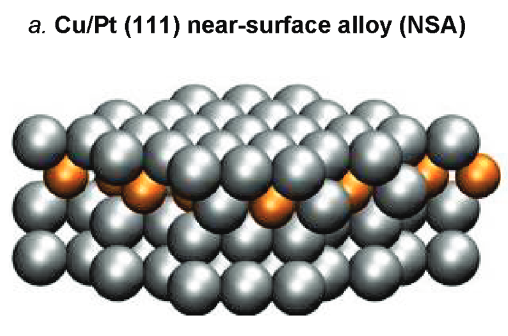

References:

https://pubs.acs.org/doi/10.1021/ja111690g

The ligand effect describes how atoms in the subsurface layers beneath the active site alter the electronic structure of the surface metal and modify its binding strength. We insert increasing fractions of Cu into the second layer of a Pt slab and observe how the OH adsorption energy changes progressively as more Cu is added.

In [19]:
def model_ligand(metal='Pt', Nx=4, Ny=4, Nz=3, ML=0):
  ref_state = reference_states[atomic_numbers[metal]]

  if not (ref_state and 'a' in ref_state):
    raise ValueError(f'Lattice constant not found for element: {metal}')

  lattice = ref_state['a']

  atoms = fcc111(metal, size=(Nx, Ny, Nz), a=lattice, vacuum=10.0)
  atoms.translate([0, 0, -4])
  atoms.pbc = [True, True, True]

  for idx in random.sample(range(Nx * Ny * (Nz - 2), Nx * Ny * (Nz - 1)), round(Nx * Ny * ML)):
    atoms[idx].symbol = 'Cu'

  target_index = Nx * Ny * (Nz - 1)

  adsorbate = Atoms('OH', positions=[
    (0, 0, 0),
    (0.7, 0, 0.7)
  ])

  add_adsorbate(atoms, adsorbate, 1.8, atoms[target_index].position[:2])

  for atom in atoms:
    if atom.index < target_index:
      atom.tag = 42
    elif atom.index >= len(atoms) - 2:
      atom.tag = 53
    else:
      atom.tag = 0

  return atoms

In [20]:
%%time
metal = 'Pt'
Nx, Ny, Nz = 2, 2, 3
rows = []

for ML in [0, 0.25, 0.50, 0.75, 1]:
  name = f'ligand_{ML}_{metal}'
  print(f'Running {name}...', flush=True)

  atoms = model_ligand(metal=metal, Nx=Nx, Ny=Ny, Nz=Nz, ML=ML)
  atoms, energy_with_OH = relax(atoms, f'{name}-OH', remove_OH=False)
  atoms, energy_without_OH = relax(atoms, f'{name}', remove_OH=True)

  rows.append({
    'metal': metal,
    'ML': ML,
    'relative_energy': energy_with_OH - energy_without_OH
  })

df_ligand = pd.DataFrame(rows)
df_ligand

Running ligand_0_Pt...
Running ligand_0.25_Pt...
Running ligand_0.5_Pt...
Running ligand_0.75_Pt...
Running ligand_1_Pt...
CPU times: user 4min 19s, sys: 305 ms, total: 4min 19s
Wall time: 1min 5s


,metal,ML,relative_energy
0,Pt,0.00,-9.662675
1,Pt,0.25,-9.634329
2,Pt,0.50,-9.543274
3,Pt,0.75,-9.606218
4,Pt,1.00,-9.307186


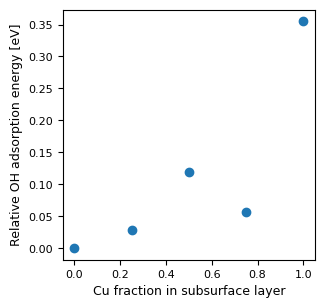

In [21]:
reference_energy = df_ligand.loc[df_ligand['ML'] == 0, 'relative_energy'].values[0]
df_ligand['relative_energy_difference'] = df_ligand['relative_energy'] - reference_energy

plt.figure()
plt.plot(df_ligand['ML'], df_ligand['relative_energy_difference'], marker='o', linestyle='')
plt.xlabel('Cu fraction in subsurface layer')
plt.ylabel('Relative OH adsorption energy [eV]')
plt.show()

!mkdir -p ligand_effect && mv ligand_*.traj ligand_*.log ligand_effect/

## Coordination Effect

The coordination effect in metal phthalocyanine (MPc) catalysts describes how changing the fifth coordination ligand (a molecule or ion attached to the metal center) influences the adsorption of intermediates, such as O, OH, and OOH, at the sixth coordination site. In MPc, the metal center binds to the phthalocyanine ring and can also coordinate with additional ligands. The nature of the fifth ligand alters the electronic environment of the metal, affecting its ability to bind intermediates at the sixth site.

For example, introducing different ions (e.g., SCN⁻ or halides) as the fifth ligand can adjust the electron density on the metal, thereby tuning the binding strength of oxygen-related intermediates. This change can enhance or reduce the activity of the catalyst in reactions like ORR by optimizing the adsorption energies of these intermediates. Thus, the coordination effect is a powerful way to control catalytic properties in MPc-based systems.

References:

JASINSKI, R. A New Fuel Cell Cathode Catalyst. Nature 201, 1212–1213 (1964). https://doi.org/10.1038/2011212a0

Ana Pizarro, Gabriel Abarca, Cristian Gutiérrez-Cerón, Diego Cortés-Arriagada, Fabiano Bernardi, Cristhian Berrios, Juan F. Silva, Marcos C. Rezende, José H. Zagal, Rubén Oñate, and Ingrid Ponce
ACS Catalysis 2018 8 (9), 8406-8419
DOI: 10.1021/acscatal.8b01479

iera M, Riquelme J, Aliaga C, Marco JF, Orellana W, Zagal JH and Tasca F (2020) Oxygen Reduction Reaction at Penta-Coordinated Co Phthalocyanines. Front. Chem. 8:22. doi: 10.3389/fchem.2020.00022

In [22]:
FePc = pubchem_atoms_search(smiles='C1=CC=C2C(=C1)C3=NC4=NC(=NC5=NC(=NC6=NC(=NC2=N3)C7=CC=CC=C76)C8=CC=CC=C85)C9=CC=CC=C94')
FePc += Atom('Fe')

for atom in FePc:
  atom.position[2] = 0

##-Relax FePc with UMA
FePc.pbc = [False, False, False]
FePc.calc = calc

opt = FIRE(FePc, trajectory='FePc.traj', logfile='FePc.log')
opt.run(fmax=0.05, steps=50)

view(FePc, viewer='x3d')

/usr/local/lib/python3.12/dist-packages/ase/data/pubchem.py:76: UserWarning: The structure "C1=CC=C2C(=C1)C3=NC4=NC(=NC5=NC(=NC6=NC(=NC2=N3)C7=CC=CC=C76)C8=CC=CC=C85)C9=CC=CC=C94" has more than one conformer in PubChem. By default, the first conformer is returned, please ensure you are using the structure you intend to or use the `ase.data.pubchem.pubchem_conformer_search` function
  warnings.warn(


In [23]:
%%time
rows = []

for ion in ['SCN', 'CN', 'Cl', 'Br', 'I', 'OH']:
  name = f'ion_{ion}_FePc'
  print(f'Running {name}...', flush=True)

  atoms = FePc.copy()

  ion_atoms = [
    Atom(symbol.capitalize(), (0, 0, -1.8 - i))
    for i, symbol in enumerate(ion)
    if symbol.isupper()
  ]

  atoms += Atoms(ion_atoms)
  atoms += Atoms('OH', positions=[
    (0, 0, 1.8),
    (0.7, 0, 2.5)
  ])

  for atom in atoms:
    if atom.index < len(FePc) - 1:
      atom.tag = 42
    elif atom.index >= len(atoms) - 2:
      atom.tag = 53
    else:
      atom.tag = 0

  atoms, energy_with_OH = relax(atoms, f'{name}-OH', remove_OH=False)
  atoms, energy_without_OH = relax(atoms, f'{name}', remove_OH=True)

  rows.append({
    'ion': ion,
    'relative_energy': energy_with_OH - energy_without_OH
  })

df_ion = pd.DataFrame(rows)
df_ion

Running ion_SCN_FePc...
Running ion_CN_FePc...
Running ion_Cl_FePc...
Running ion_Br_FePc...
Running ion_I_FePc...
Running ion_OH_FePc...
CPU times: user 14min 40s, sys: 15 s, total: 14min 55s
Wall time: 3min 44s


,ion,relative_energy
0,SCN,-8.887497
1,CN,-9.527984
2,Cl,-8.692049
3,Br,-8.940178
4,I,-9.671995
5,OH,-9.319990


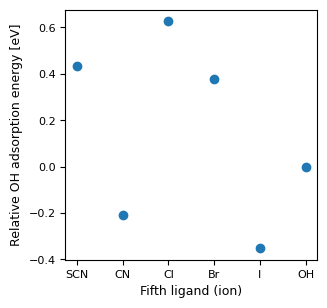

In [24]:
reference_energy = df_ion.loc[df_ion['ion'] == 'OH', 'relative_energy'].values[0]
df_ion['relative_energy_difference'] = df_ion['relative_energy'] - reference_energy

plt.figure()
plt.plot(df_ion['ion'], df_ion['relative_energy_difference'], marker='o', linestyle='')
plt.xlabel('Fifth ligand (ion)')
plt.ylabel('Relative OH adsorption energy [eV]')
plt.show()

#Summary

After completing this notebook, you should understand and compute:

1. Metals with a d-band center closer to the Fermi level bind OH more strongly. Confirm this by computing OH adsorption energies on Pt, Pd, Ir, and Ag and plotting against literature Hammer-Nørskov d-band center values.
2. Different surface orientations (111, 100, 110, 211) expose atoms with different coordination numbers. Lower coordination (more undercoordinated surface sites, as on stepped 211) generally strengthens OH binding. Quantify this using the scaled coordination number computed from NeighborList.
3. Stretching the Pt(111) lattice (tensile strain) narrows the d-band and shifts it upward, strengthening OH binding. Compressive strain does the opposite. Verify by scanning lattice parameters from -2% to +1% relative to equilibrium.
4. Bending a flat M-N-C sheet into a curved geometry changes bond angles at the metal center and modifies the adsorption energy. Plot adsorption energy against inverse squared radius (the curvature 1/r²) for a NiN₄ nanoribbon at radii from 4 to 1000 Å.
5. Substituting Cu into the subsurface layer beneath a Pt surface changes the electron density at the Pt binding site through-bond. Track the adsorption energy shift as the Cu fraction in the second layer increases from 0 to 1.
6. In FePc, the fifth axial ligand (SCN⁻, CN⁻, Cl⁻, Br⁻, I⁻, OH⁻) modulates the electron density at the Fe center and shifts the OH binding energy at the sixth coordination site. Build FePc from a SMILES string via PubChem, add the axial ion and OH adsorbate programmatically, and plot the energy shift across the ion series.